In [1]:
import pandas as pd 
import numpy as np 

In [2]:
import pyecoacc as acc 
from pyecoacc.models.pipeline import get_default_random_forest_pipeline
from pyecoacc.util.analytics import compute_confusion_matrix
from pyecoacc.util.time_budget import compute_time_budget

# Load 

In [3]:
molerats_data = pd.read_csv("data/molerats.csv", index_col=0)

In [4]:
# This is only for the demonstration, don't do this for actual model training! 
# Take first 150 of each behavior for training 
# Take next 150 of each behavior for confusion matrix estimation 
# All remaining samples will be used for time budgets 

molerats_data = molerats_data.sample(frac=1)  # shuffle 
molerats_data.drop("Animal", inplace=True, axis=1)

train = molerats_data.groupby("Behavior").head(150).copy()
val = molerats_data.groupby("Behavior").apply(lambda x: x.iloc[150:300]).copy()
for_time_budget = molerats_data.groupby("Behavior").apply(lambda x: x.iloc[200:]).copy()

# Model 

In [5]:
model = get_default_random_forest_pipeline()

In [6]:
X = train.iloc[:, :-1].values 
y = train.Behavior.values 
model.fit(X, y)

Pipeline(steps=[('features', ACCStatsTransformer()),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=250))])

In [7]:
X_test = val.iloc[:, :-1].values 
y_test = val.Behavior.values 
y_hat = model.predict(X_test)

cm = compute_confusion_matrix(y_test, y_hat)
cm

,Dig,Eat,Forward Loco,Rest,Stand,Sweep
Dig,0.79,0.03,0.07,0.00,0.04,0.07
Eat,0.01,0.83,0.08,0.00,0.07,0.01
Forward Loco,0.08,0.03,0.74,0.01,0.05,0.09
Rest,0.00,0.00,0.00,0.95,0.05,0.00
Stand,0.03,0.10,0.05,0.07,0.75,0.01
Sweep,0.12,0.01,0.05,0.00,0.03,0.79


# Compte time budgets 
- show real (ground truth)tb 
- show estimated with and without confusion matrix correction 

In [8]:
real_tb = for_time_budget.Behavior.value_counts(normalize=True)

In [9]:
X = for_time_budget.iloc[:, :-1].values 

In [10]:
estimated_tb_with_cm = compute_time_budget(X, model, cm)
estimated_tb_without_cm = compute_time_budget(X, model, cm=None, apply_cm_correction=False)

<Axes: >

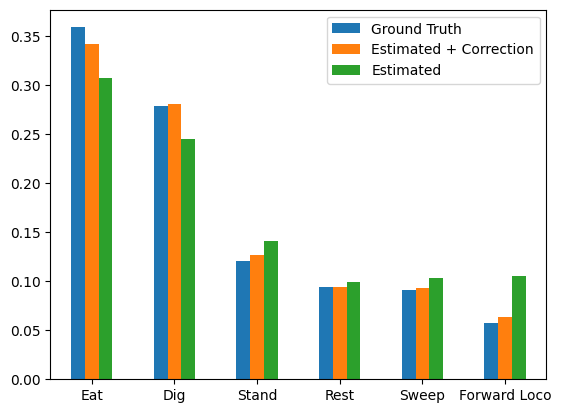

In [11]:
pd.DataFrame([real_tb, estimated_tb_with_cm, estimated_tb_without_cm], 
             index=["Ground Truth", "Estimated + Correction", "Estimated"]).T.plot(kind="bar", rot=0)